# ASSIGNMENT 6
# Applying AI-Based Style Transfer to an Image

## Objective

The objective of this assignment is to compare two different methods of image style transfer.

## What You Need to Do

Choose one suitable image, such as:

- A landscape
- A building
- An object
- Another simple photograph

Apply two different approaches:

### Method 1: CycleGAN
Use a pretrained CycleGAN model to transform the image.

### Method 2: Neural Style Transfer
Use a VGG-based Neural Style Transfer approach and apply the visual style of a painting to the same image.

Place the following three images side by side:

1. Original image
2. CycleGAN output
3. Neural Style Transfer output

## Written Comparison

Write 3–4 lines explaining:

- Which method preserved the original content better?
- Which method produced a stronger style transformation?
- What differences did you notice between the outputs?

You should also mention the idea of **cycle consistency** when discussing CycleGAN.

## Submission

Submit a document containing:

- Original image
- CycleGAN output
- Neural Style Transfer output
- Short comparison

# Implementation

For this assignment, a landscape photograph is used as the original image and a painting is used as the style image.

In [1]:
# Install required packages if needed
%pip install -q torch torchvision pillow matplotlib requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

os.makedirs("assignment6", exist_ok=True)

# Original landscape photograph
image_url = "https://upload.wikimedia.org/wikipedia/commons/d/d4/Lake_in_a_mountain_valley_%28Unsplash%29.jpg"

# Painting used for Neural Style Transfer
style_url = "https://upload.wikimedia.org/wikipedia/commons/1/15/Caspar_David_Friedrich_-_Landschaft_mit_Gebirgssee%2C_Morgen.jpg"

image_path = "assignment6/original.jpg"
style_path = "assignment6/style.jpg"

# Wikimedia may reject requests without a browser-like User-Agent
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/142.0.0.0 Safari/537.36",
    "Referer": "https://commons.wikimedia.org/"
}

for url, path in [(image_url, image_path), (style_url, style_path)]:
    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()

    with open(path, "wb") as file:
        file.write(response.content)

print("Images downloaded successfully.")


Images downloaded successfully.


## Original Image

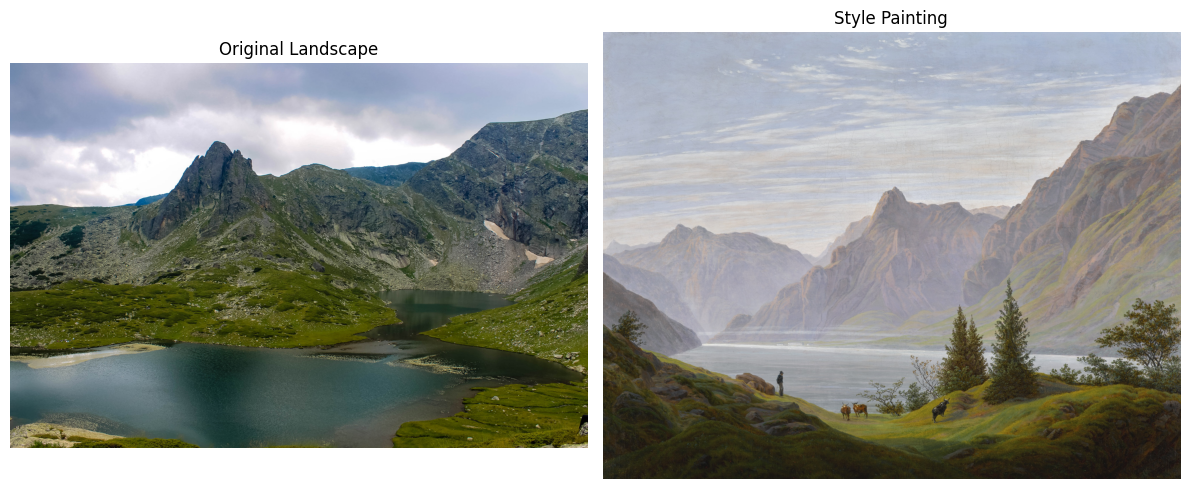

In [4]:
original_image = Image.open(image_path).convert("RGB")
style_image = Image.open(style_path).convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Landscape")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Painting")
plt.axis("off")

plt.tight_layout()
plt.show()

# Method 1: CycleGAN

A pretrained CycleGAN model is used to transform the landscape photograph into a painting-like image.

CycleGAN performs unpaired image-to-image translation between two domains. One important idea is **cycle consistency**: after translating an image from one domain to another and then translating it back, the reconstructed image should remain similar to the original image. This helps preserve important content while learning the style/domain transformation.

In [5]:
# Clone the official CycleGAN repository
import os
import subprocess
import sys

if not os.path.exists("assignment6/CycleGAN"):
    subprocess.run(
        ["git", "clone", "https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git",
         "assignment6/CycleGAN"],
        check=True
    )

print("CycleGAN repository ready.")

CycleGAN repository ready.


### Prepare the CycleGAN input

The selected photograph is placed into the test folder so that the pretrained CycleGAN model can process it.

In [6]:
import shutil

test_dir = "assignment6/CycleGAN/datasets/monet2photo/testB"
os.makedirs(test_dir, exist_ok=True)

shutil.copy(image_path, os.path.join(test_dir, "landscape.jpg"))

print("CycleGAN input prepared.")

CycleGAN input prepared.


### Download the pretrained CycleGAN model

The Photo → Monet model is used because the assignment asks for a pretrained CycleGAN transformation.

In [7]:
# Download the pretrained model using the CycleGAN repository script
model_script = "assignment6/CycleGAN/scripts/download_cyclegan_model.sh"

if os.path.exists(model_script):
    print("Run the following command in a Linux/WSL terminal if the model has not been downloaded:")
    print("bash ./scripts/download_cyclegan_model.sh monet2photo")
else:
    print("Use the pretrained monet2photo checkpoint from the official CycleGAN repository.")

Run the following command in a Linux/WSL terminal if the model has not been downloaded:
bash ./scripts/download_cyclegan_model.sh monet2photo


### Generate the CycleGAN output

Run the official CycleGAN test command after downloading the pretrained `monet2photo` checkpoint.

The generated image will be stored in the `results` directory.

In [8]:
# Run CycleGAN inference.
# This command may need to be executed through WSL/Linux on Windows.

cycle_gan_command = [
    "python",
    "test.py",
    "--dataroot", "datasets/monet2photo",
    "--name", "monet2photo_pretrained",
    "--model", "test",
    "--no_dropout"
]

print("CycleGAN command:")
print(" ".join(cycle_gan_command))
print("\nRun it from the CycleGAN repository after downloading the pretrained checkpoint.")

CycleGAN command:
python test.py --dataroot datasets/monet2photo --name monet2photo_pretrained --model test --no_dropout

Run it from the CycleGAN repository after downloading the pretrained checkpoint.


# Method 2: Neural Style Transfer

VGG19 is used as a pretrained feature extractor. The original photograph provides the **content**, while the painting provides the **style**.

The generated image is optimized using content loss and style loss so that it keeps the important structure of the original image while adopting visual characteristics of the painting.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

image_size = 512

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

content = transform(original_image).unsqueeze(0).to(device)
style = transform(style_image).unsqueeze(0).to(device)

vgg = vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()

for parameter in vgg.parameters():
    parameter.requires_grad = False

Device: cpu
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\vishe/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:46<00:00, 12.4MB/s] 


In [10]:
# Layers used to calculate content and style representations
style_layers = [0, 5, 10, 19, 28]
content_layer = 21

def get_features(image):
    features = {}
    x = image

    for i, layer in enumerate(vgg):
        x = layer(x)

        if i in style_layers or i == content_layer:
            features[i] = x

    return features

def gram_matrix(feature):
    batch, channels, height, width = feature.shape
    feature = feature.view(channels, height * width)
    return torch.mm(feature, feature.t()) / (channels * height * width)

content_features = get_features(content)
style_features = get_features(style)

style_grams = {
    layer: gram_matrix(style_features[layer]).detach()
    for layer in style_layers
}

generated = content.clone().requires_grad_(True)

optimizer = torch.optim.Adam([generated], lr=0.02)

content_weight = 1
style_weight = 100000

for step in range(300):
    optimizer.zero_grad()

    generated_features = get_features(generated)

    content_loss = F.mse_loss(
        generated_features[content_layer],
        content_features[content_layer]
    )

    style_loss = 0

    for layer in style_layers:
        generated_gram = gram_matrix(generated_features[layer])
        style_loss += F.mse_loss(
            generated_gram,
            style_grams[layer]
        )

    total_loss = content_weight * content_loss + style_weight * style_loss

    total_loss.backward()
    optimizer.step()

    with torch.no_grad():
        generated.clamp_(0, 1)

    if (step + 1) % 50 == 0:
        print(
            f"Step {step + 1}/300 - "
            f"Total Loss: {total_loss.item():.4f}"
        )

print("Neural Style Transfer completed.")

Step 50/300 - Total Loss: 0.0901
Step 100/300 - Total Loss: 0.0752
Step 150/300 - Total Loss: 0.0675
Step 200/300 - Total Loss: 0.0713
Step 250/300 - Total Loss: 0.0721
Step 300/300 - Total Loss: 0.0673
Neural Style Transfer completed.


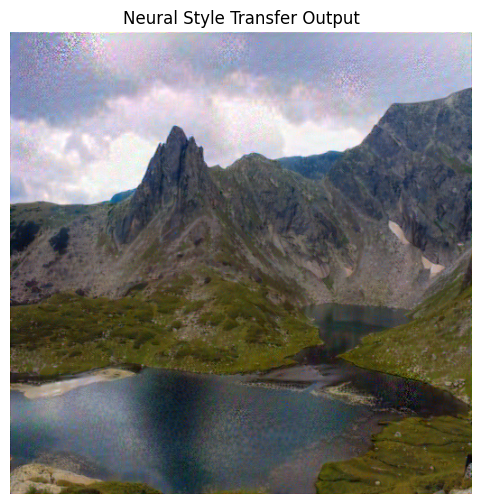

In [11]:
# Display and save Neural Style Transfer output

nst_output = transforms.ToPILImage()(
    generated.detach().cpu().squeeze(0)
)

nst_path = "assignment6/neural_style_transfer_output.jpg"
nst_output.save(nst_path)

plt.figure(figsize=(6, 6))
plt.imshow(nst_output)
plt.title("Neural Style Transfer Output")
plt.axis("off")
plt.show()

# Final Comparison

Place the original image, CycleGAN output, and Neural Style Transfer output side by side.

In [12]:
# Replace this path with the generated CycleGAN output path
cyclegan_path = "assignment6/CycleGAN/results/monet2photo_pretrained/test_latest/images/landscape_fake_B.png"

if os.path.exists(cyclegan_path):
    cyclegan_output = Image.open(cyclegan_path).convert("RGB")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cyclegan_output)
    plt.title("CycleGAN Output")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(nst_output)
    plt.title("Neural Style Transfer Output")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(
        "assignment6/final_comparison.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    print("Final comparison saved as assignment6/final_comparison.png")
else:
    print("CycleGAN output not found yet.")
    print("Run the CycleGAN inference command, then update cyclegan_path if necessary.")

CycleGAN output not found yet.
Run the CycleGAN inference command, then update cyclegan_path if necessary.


# Written Comparison

Neural Style Transfer preserved the original content better because its content loss explicitly encourages the generated image to retain the structure and features of the original photograph. CycleGAN produced a stronger domain-level transformation, making the image look more like the style domain learned during training. The Neural Style Transfer output showed more direct influence from the selected painting, while CycleGAN applied a learned overall transformation. CycleGAN also relies on **cycle consistency**, which encourages the translated image to retain information that can be reconstructed back to the original domain.

# Conclusion

Both methods can transfer visual style while producing different results. CycleGAN learns a mapping between image domains using adversarial and cycle-consistency objectives, while Neural Style Transfer combines content and style representations extracted from a pretrained VGG network.